## Import Statement


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Formatting Notebook


In [5]:
pd.options.display.float_format = "{:,.2f}".format

## Reading the files


In [6]:
monthly_df = pd.read_csv(r"data/monthly_deaths.csv")
yearly_df = pd.read_csv(r"data/annual_deaths_by_clinic.csv")

### Conversion to DateTime objects


In [11]:
monthly_df["date"] = pd.to_datetime(monthly_df["date"])

monthly_df.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


### Finding any duplicates of NaN values in the DataFrames


##### Monthly DataFrames


In [12]:
print(monthly_df.isna().sum().sum())
print(monthly_df.duplicated().sum())

0
0


##### Yearly DataFrames


In [13]:
print(yearly_df.isna().sum().sum())
print(yearly_df.duplicated().sum())

0
0


### Descriptive Analysis


#### Yearly Analysis


In [38]:
yearly_df.describe()

,year,births,deaths
count,12.00,12.00,12.00
mean,"1,843.50","3,152.75",223.33
std,1.78,449.08,145.38
min,"1,841.00","2,442.00",66.00
25%,"1,842.00","2,901.75",100.25
50%,"1,843.50","3,108.50",219.50
75%,"1,845.00","3,338.25",263.50
max,"1,846.00","4,010.00",518.00


#### Monthy Analysis


In [39]:
monthly_df.describe()

,date,births,deaths
count,98,98.00,98.00
mean,1845-02-11 04:24:29.387755008,267.00,22.47
min,1841-01-01 00:00:00,190.00,0.00
25%,1843-02-08 00:00:00,242.50,8.00
50%,1845-02-15 00:00:00,264.00,16.50
75%,1847-02-22 00:00:00,292.75,36.75
max,1849-03-01 00:00:00,406.00,75.00
std,NaN,41.77,18.14


### Visualize the No. of Births and Deaths


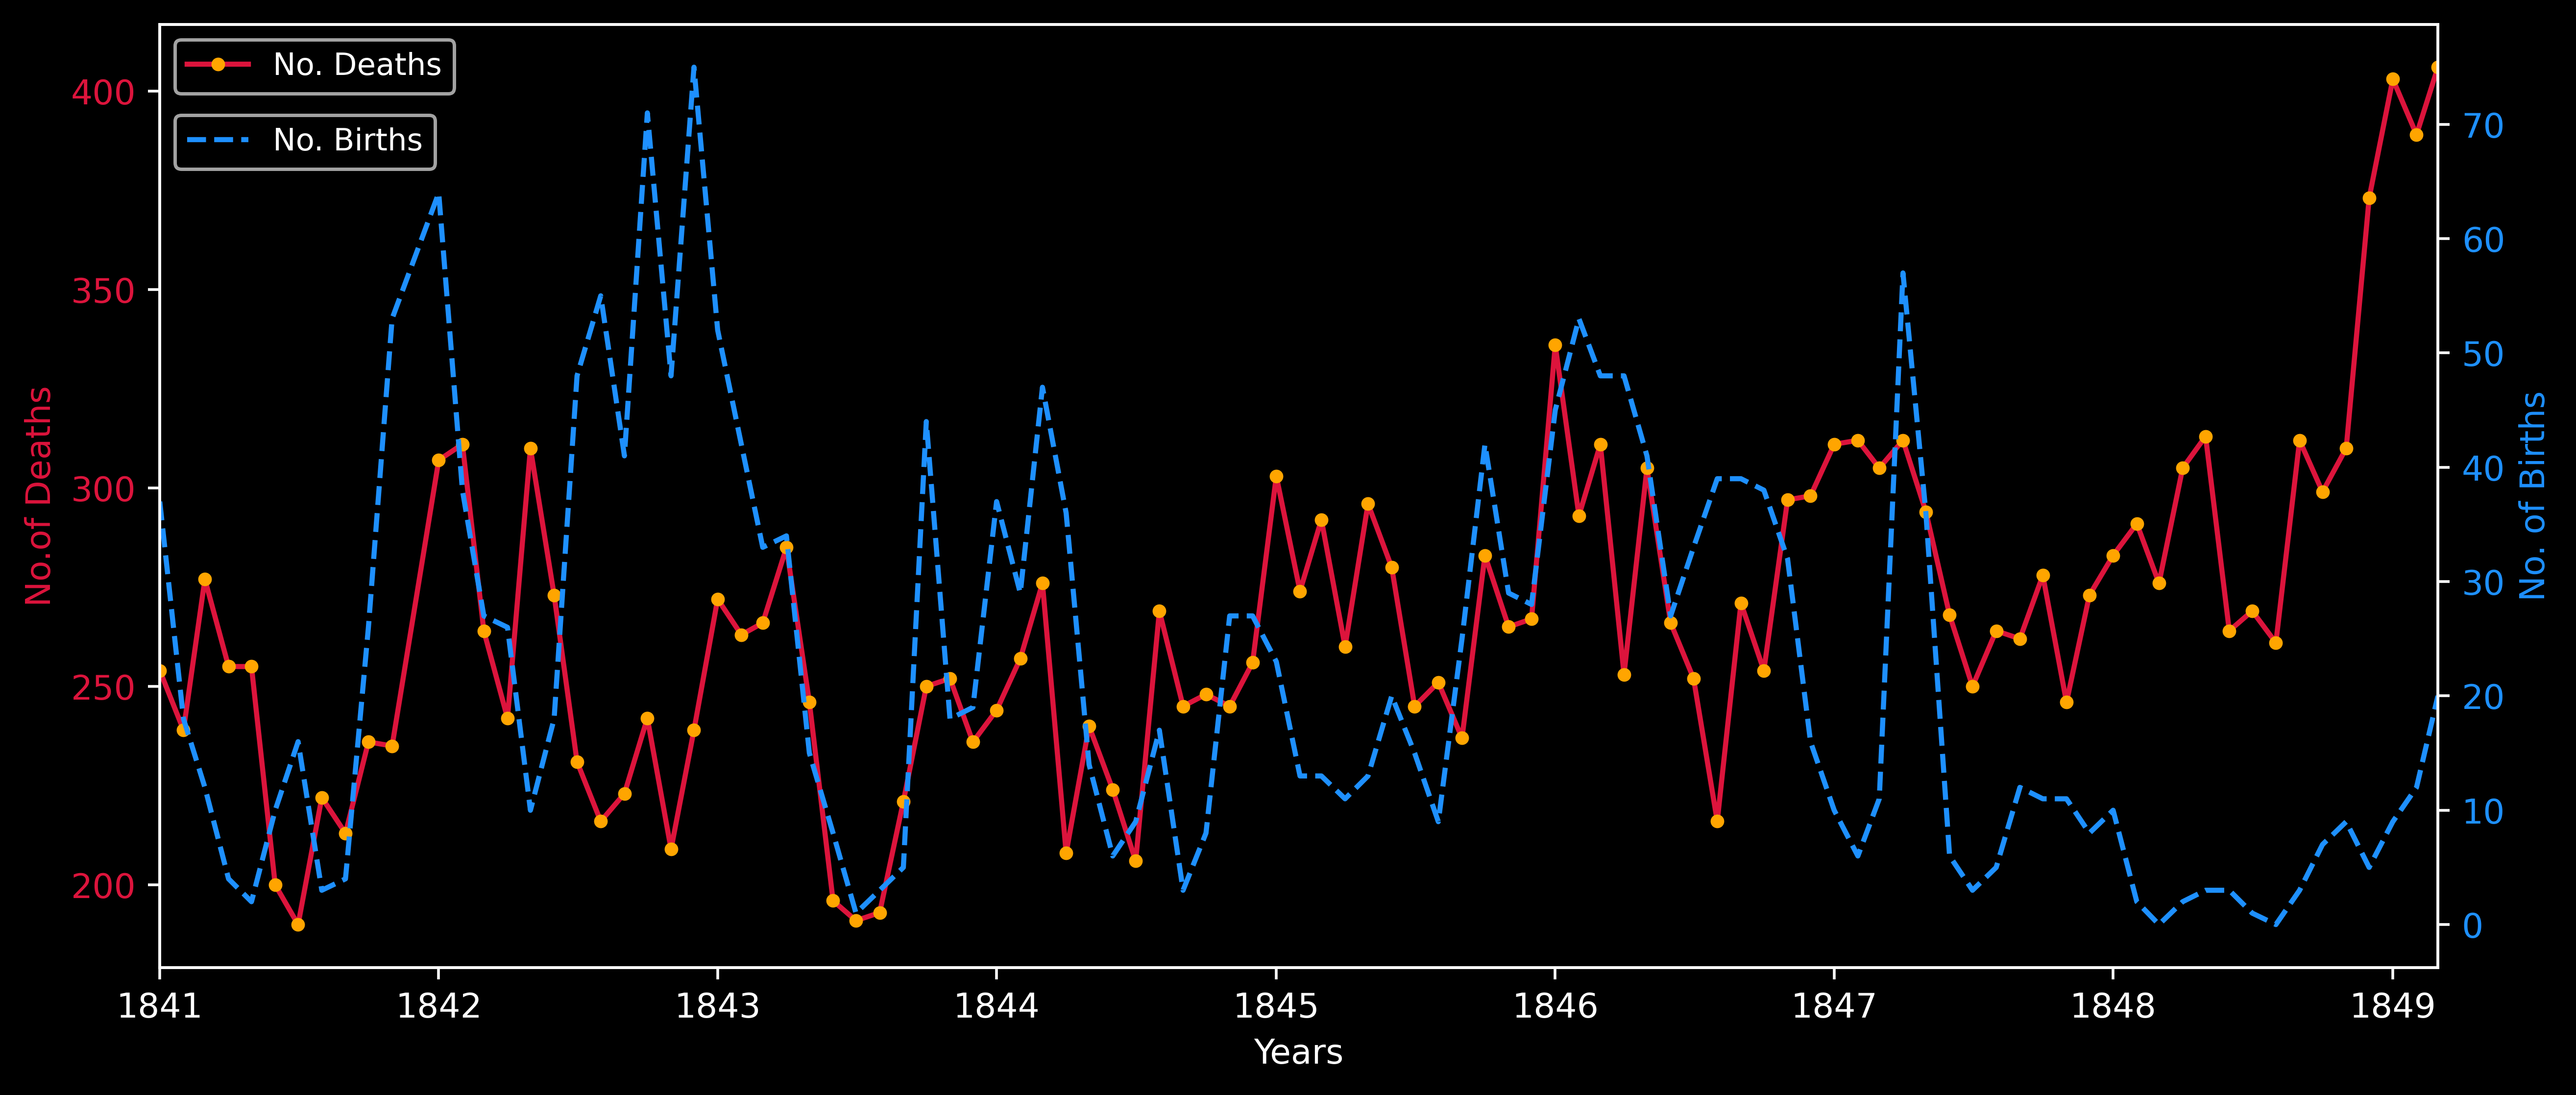

In [123]:
# Setting Coordinates:
XCOR = monthly_df["date"]
YCOR_1 = monthly_df["births"]
YCOR_2 = monthly_df["deaths"]

# Plotting:
plt.figure(figsize=(12, 5), dpi=500)
plt.xlim(XCOR.min(), XCOR.max())

axis1 = plt.gca()
axis2 = axis1.twinx()

# Setting Labels:
axis1.set_xlabel("Years")
axis1.set_ylabel("No.of Deaths", color="crimson")
axis2.set_ylabel("No. of Births", color="dodgerblue")

# Styling Labels:
axis1.tick_params(axis="y", labelcolor="crimson")
axis2.tick_params(axis="y", labelcolor="dodgerblue")


axis1.plot(
    XCOR,
    YCOR_1,
    color="crimson",
    label="No. Deaths",
    marker=".",
    markerfacecolor="orange",
    markeredgecolor="orange",
)

axis2.plot(
    XCOR,
    YCOR_2,
    label="No. Births",
    linestyle="--",
    color="dodgerblue",
)

axis1.legend(loc="upper left", bbox_to_anchor=(0, 1), fontsize=9)
axis2.legend(loc="upper left", bbox_to_anchor=(0, 0.92), fontsize=9)

plt.show()

#### Percentage of Women Deaths


In [40]:
pct_women_deaths = yearly_df["deaths"].sum() / yearly_df["births"].sum() * 100
print(f"Percentage of Women Dying in ChildBirth {pct_women_deaths:.2f}%")

Percentage of Women Dying in ChildBirth 7.08%


### Plotting the Births & Deaths w.r.t Clinics


##### Birth Count wrt to Clinics


In [152]:
# Setting Coordinates:
DF = yearly_df
XCOR = "year"
YCOR = "births"

# Setting Labels:
TITLE = "No. of Birth w.r.t to Clinic"
XLABEL = "Years"
YLABEL = "No. Births"


line = px.line(
    title=TITLE,
    data_frame=DF,
    x=XCOR,
    y=YCOR,
    color="clinic",
    markers="o",
    color_discrete_sequence=["#000080", "orange"],
)

line.update_layout(
    xaxis_title=XLABEL,
    yaxis_title=YLABEL,
    legend_title_text="Clinic",
)

line.show()

#### Deaths count w.r.t Clinic:


In [151]:
# Setting Coordinates:
DF = yearly_df
XCOR = "year"
YCOR = "deaths"

# Setting Label:
TITLE = "Death w.r.t to clinic"
XLABEL = "Years"
YLABEL = "Deaths"

line = px.line(
    data_frame=DF,
    x=XCOR,
    y=YCOR,
    title=TITLE,
    markers=".",
    color="clinic",
    color_discrete_sequence=["orange", "magenta"],
)

line.update_layout(xaxis_title=XLABEL, yaxis_title=YLABEL, legend_title_text="Clinic")

line.show()

### Propotional Death at Each Clinic:


In [72]:
pct_deaths = yearly_df["deaths"] / yearly_df["births"]
yearly_df["pct_deaths"] = pct_deaths

clinic_1 = yearly_df[yearly_df["clinic"] == "clinic 1"]
clinic_2 = yearly_df[yearly_df["clinic"] == "clinic 2"]


avg_clinic_1_births = clinic_1["births"].sum() / clinic_1["deaths"].sum()
avg_clinic_2_births = clinic_2["births"].sum() / clinic_2["deaths"].sum()

### Effects before and after Handwashing


In [98]:
starting_date: str = "1845-06-01"

pct_deaths = monthly_df["deaths"] / monthly_df["births"]
monthly_df["pct_deaths"] = pct_deaths

before_handwashing = monthly_df[monthly_df["date"] < starting_date]
after_handwashing = monthly_df[monthly_df["date"] >= starting_date]

### Death Count Before & After Handwashing


In [99]:
deaths_before_HW = (
    before_handwashing["deaths"].sum() / before_handwashing["births"].sum() * 100
)

deaths_after_HW = (
    after_handwashing["deaths"].sum() / after_handwashing["births"].sum() * 100
)

print(f"Deaths before Hand Washing {deaths_before_HW:.2f}%")
print(f"Deaths after Hand Washing {deaths_after_HW:.2f}%")

Deaths before Hand Washing 10.21%
Deaths after Hand Washing 6.68%


### 6 months of Moving average


In [135]:
rolling_df = before_handwashing.set_index("date")
rolling_df = rolling_df.rolling(window=6).mean()

rolling_df.sample()

,births,deaths,pct_deaths
date,,,
1842-07-01,271.83,27.83,0.11


### Monthly Average Births & Deaths


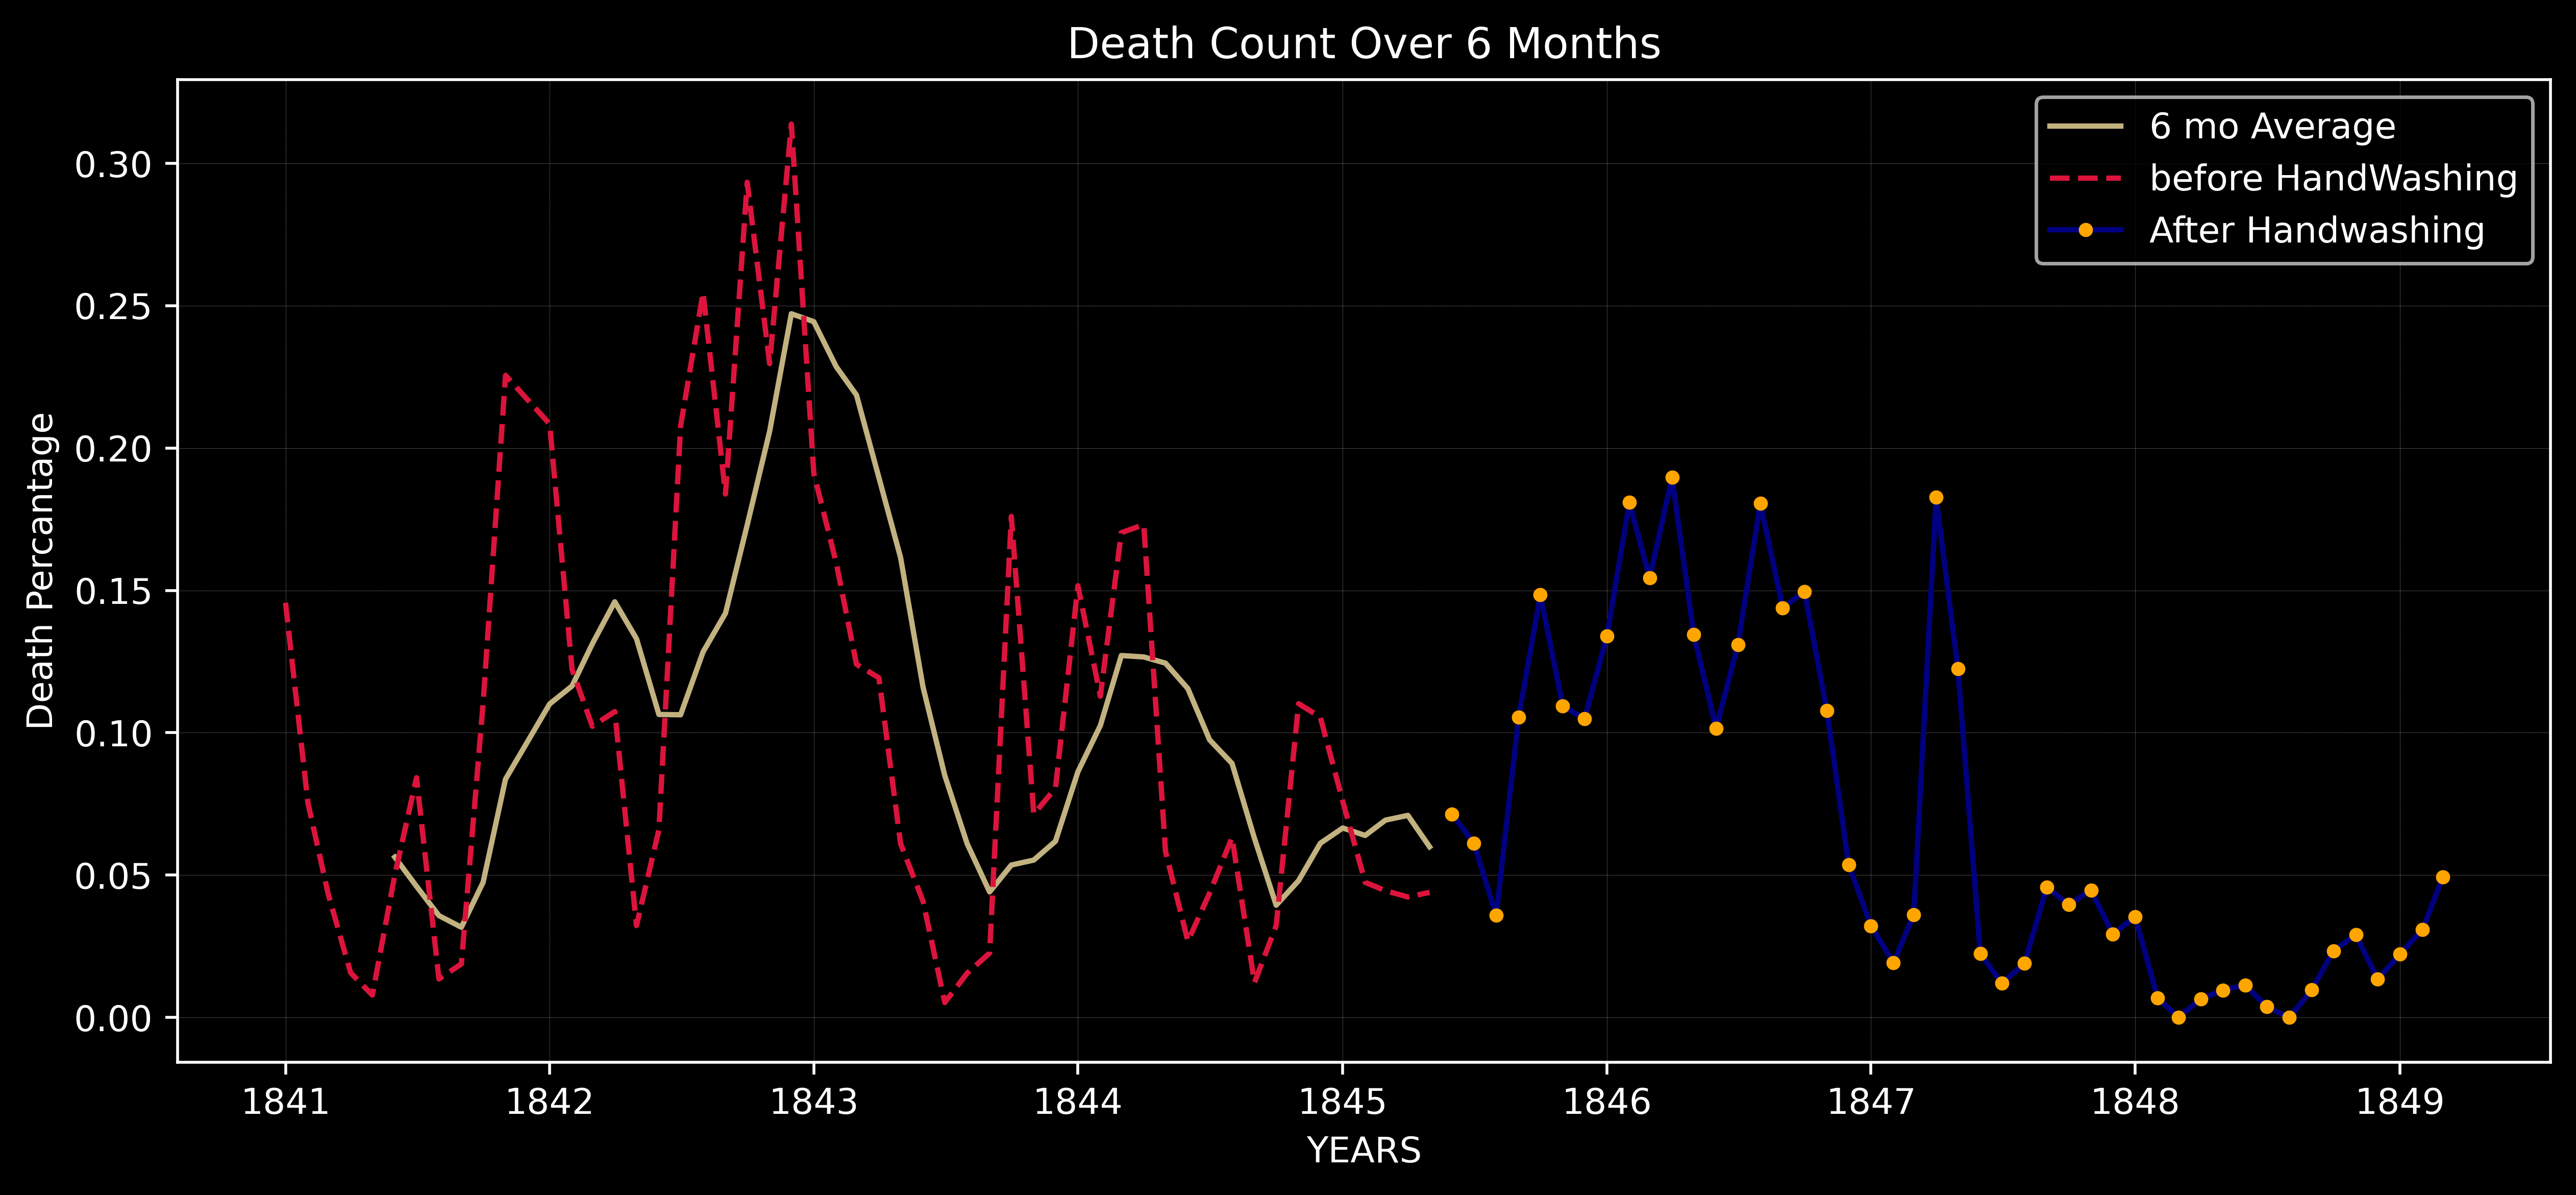

In [131]:
plt.figure(figsize=(12, 5), dpi=500)

# Setting Labels:
plt.title("Death Count Over 6 Months")
plt.ylabel("Death Percantage")
plt.xlabel("YEARS")

plt.grid(visible=True, which="both", linewidth=0.1, linestyle="dotted")

axis1 = plt.gca()

(ma_line,) = plt.plot(
    rolling_df.index,
    rolling_df["pct_deaths"],
    color="#C2B280",
    label="6 mo Average",
)

(bw_line,) = plt.plot(
    before_handwashing["date"],
    before_handwashing["pct_deaths"],
    color="crimson",
    label="before HandWashing",
    linestyle="--",
)

(aw_line,) = plt.plot(
    after_handwashing["date"],
    after_handwashing["pct_deaths"],
    color="#000080",
    label="After Handwashing",
    marker=".",
    markerfacecolor="orange",
    markeredgecolor="orange",
)

plt.legend()

plt.show()

### Means Deaths Before & After Hand Washing


In [130]:
mean_death_before_hw = before_handwashing["deaths"].mean()
print(f"Mean Death Before Hand Washing {mean_death_before_hw:.2f}")

mean_death_after_hw = after_handwashing["deaths"].mean()
print(f"Mean death After Hand washing {mean_death_after_hw:.2f}")

mean_death = mean_death_before_hw - mean_death_after_hw
print(f"Relative Mean Deaths: {mean_death:.2f}")

times_death = mean_death_before_hw / mean_death_after_hw
print(f"Decrease In the Mortality Rate {times_death:.2f}x Times ")

Mean Death Before Hand Washing 25.25
Mean death After Hand washing 19.33
Relative Mean Deaths: 5.92
Decrease In the Mortality Rate 1.31x Times 


#### Using Numpy Conditions


In [136]:
monthly_df["washing_hands"] = np.where(monthly_df["date"] < starting_date, "No", "Yes")

### Plotly box Visualization


In [150]:
# Setting Coordinates:
DF = monthly_df
XCOR = "washing_hands"
YCOR = "pct_deaths"

# Setting Labels:
TITLE = r"Percentage of Deaths of Hand washer & Non- Hand-Washers"
XLABEL = "Hand Washing"
YLABEL = "Percentage of Deaths"


box = px.box(
    data_frame=DF,
    title=TITLE,
    x=XCOR,
    color=XCOR,
    y=YCOR,
    color_discrete_sequence=["#FFA500", "#40E0D0"],
)

box.update_layout(
    xaxis_title=XLABEL,
    yaxis_title=YLABEL,
    legend_title_text="Hand Washing",
)

box.show()

### Using the Histrogram


In [149]:
# Setting Coordinates:
DF = monthly_df
XCOR = "pct_deaths"

# Setting Labels:
TITLE = "Percentages of Deaths"
XLABEL = "Washing & Non-Washing"
YLABEL = "Percentage"

hist = px.histogram(
    data_frame=DF,
    x=XCOR,
    color="washing_hands",
    nbins=30,
    barmode="overlay",
    histnorm="percent",
    color_discrete_sequence=["#000080", "orange"],
)

hist.update_layout(
    xaxis_title=XLABEL,
    yaxis_title=YLABEL,
    legend_title_text="Hand Washing",
)

hist.show()

### Using the Seaborn KDE


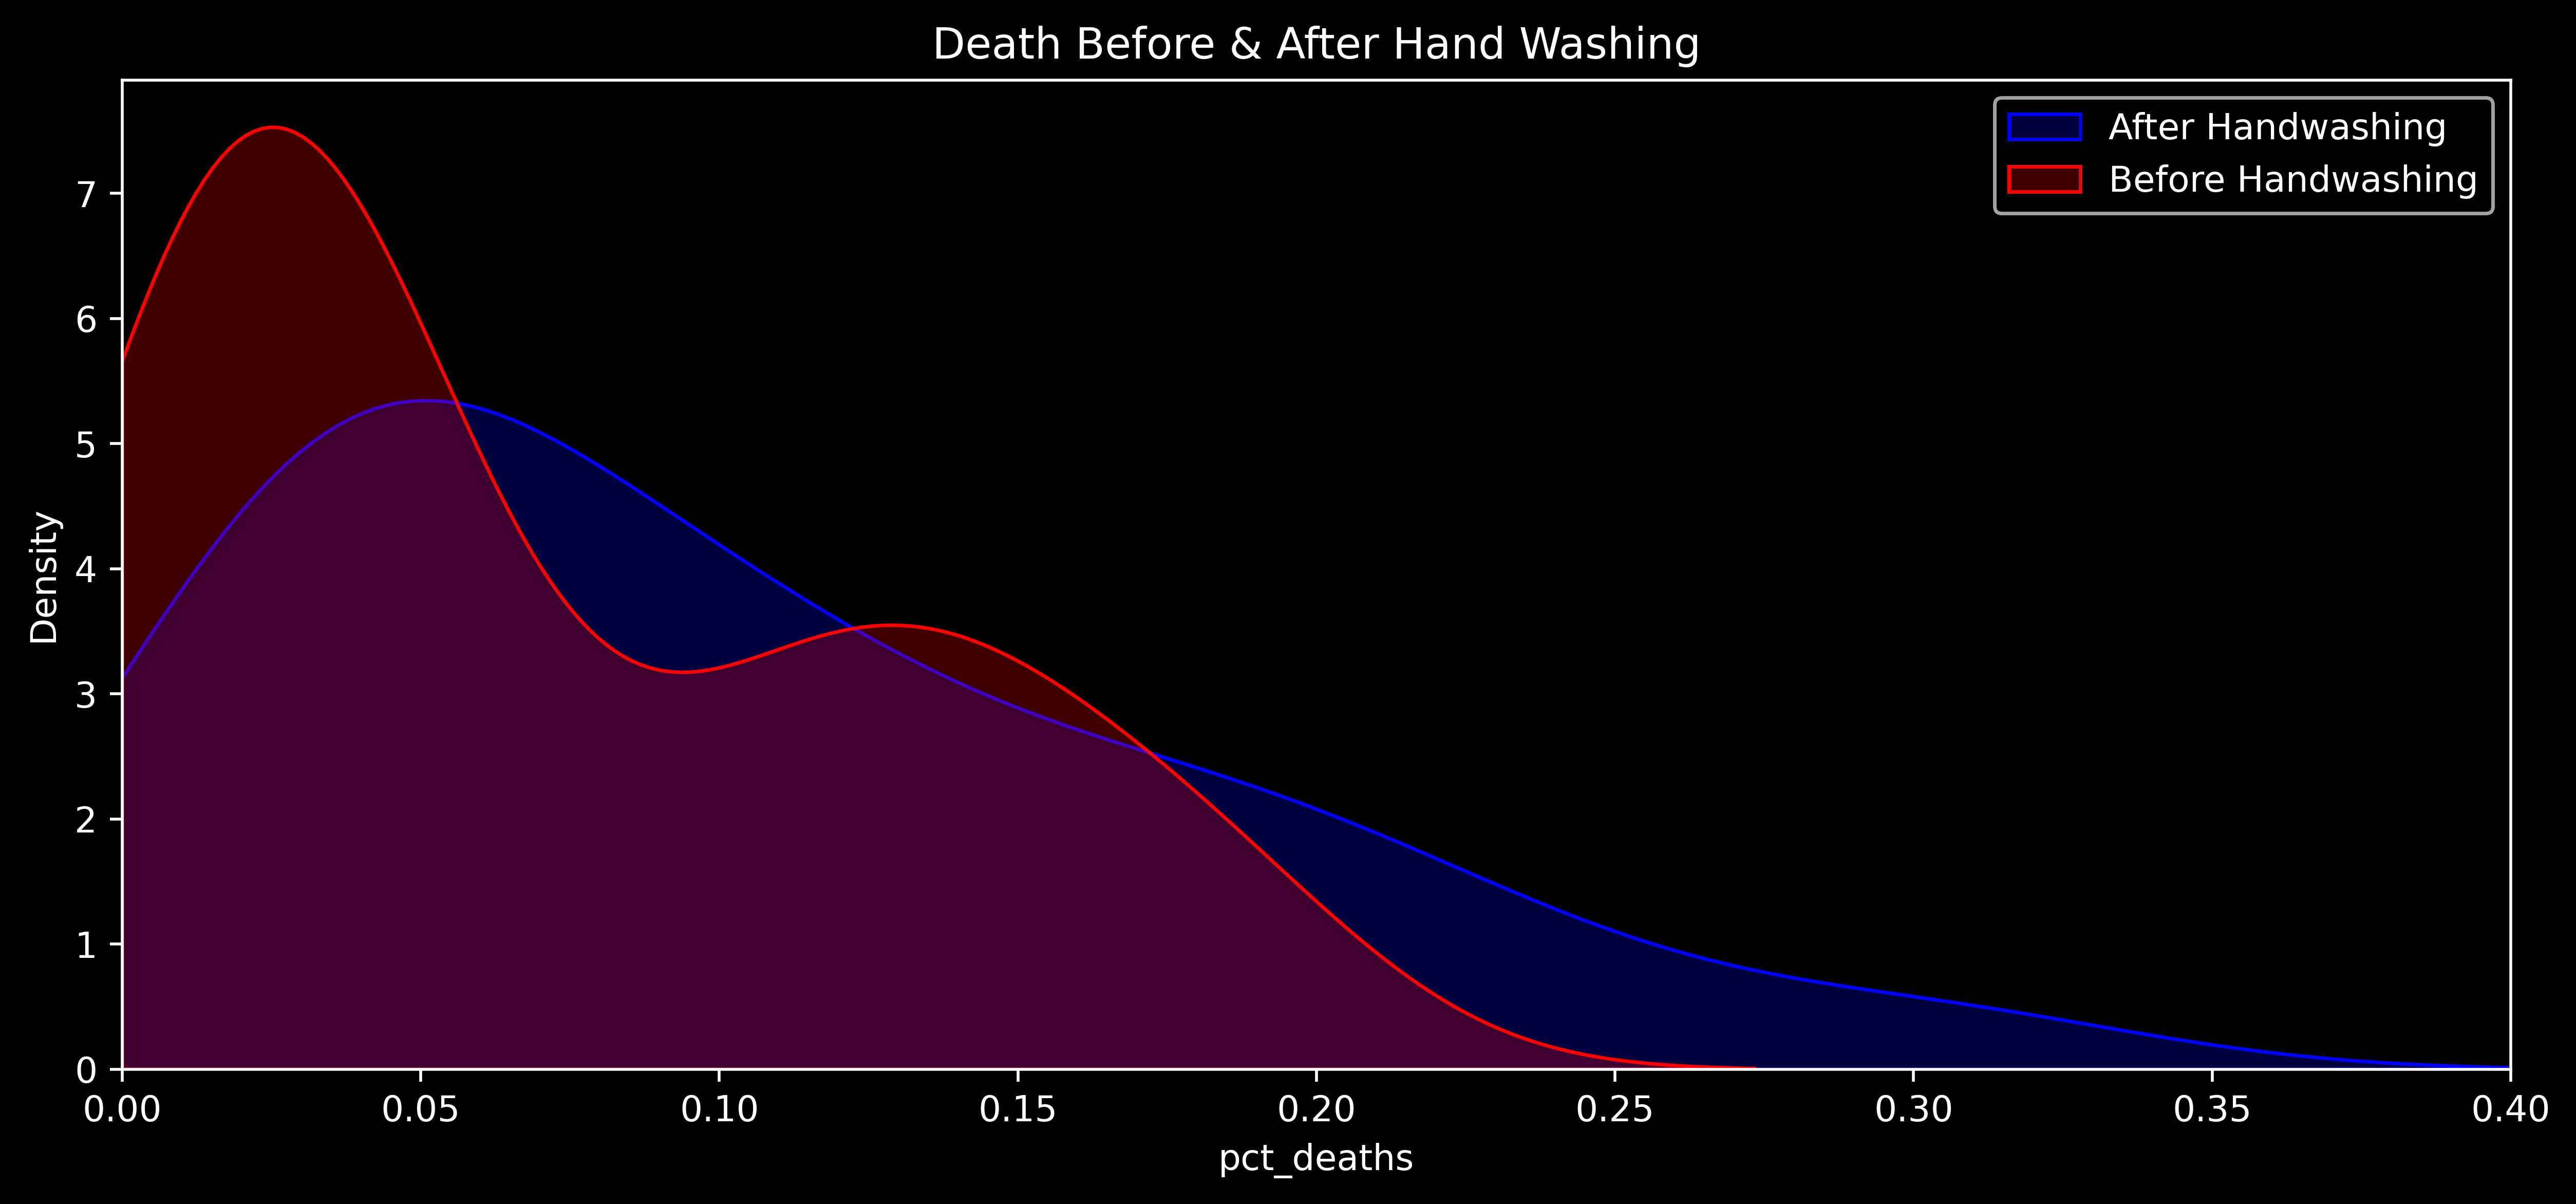

In [168]:
plt.figure(figsize=(12, 5), dpi=500)

plt.xlim(0, 0.40)

plt.title("Death Before & After Hand Washing")


sns.kdeplot(
    data=before_handwashing["pct_deaths"],
    fill=True,
    color="blue",
    clip=(0, 1),
    label="After Handwashing",
)

sns.kdeplot(
    data=after_handwashing["pct_deaths"],
    fill=True,
    color="red",
    clip=(0, 1),
    label="Before Handwashing",
)

plt.legend()

plt.show()